In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [28]:
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("Healthcare-Diabetes.csv")

In [30]:
df.head()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1


In [31]:
df = df.drop(columns = ['Id'])

In [32]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000
mean,3.742775,121.102601,69.134393,20.824422,80.127890,32.137392,0.471193,33.132225,0.343931
std,3.323801,32.036508,19.231438,16.059596,112.301933,8.076127,0.325669,11.777230,0.475104
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,37.000000,32.200000,0.375000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.625000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,846.000000,80.600000,2.420000,81.000000,1.000000


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2768 non-null   int64  
 1   Glucose                   2768 non-null   int64  
 2   BloodPressure             2768 non-null   int64  
 3   SkinThickness             2768 non-null   int64  
 4   Insulin                   2768 non-null   int64  
 5   BMI                       2768 non-null   float64
 6   DiabetesPedigreeFunction  2768 non-null   float64
 7   Age                       2768 non-null   int64  
 8   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 194.8 KB


In [34]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

<Axes: xlabel='Outcome'>

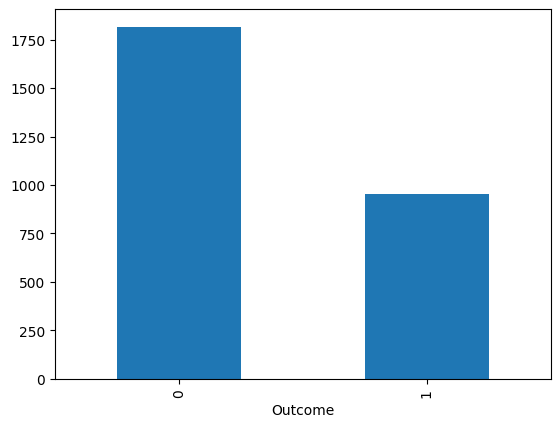

In [35]:
df.Outcome.value_counts().plot.bar()

In [36]:
import seaborn as sns

In [37]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

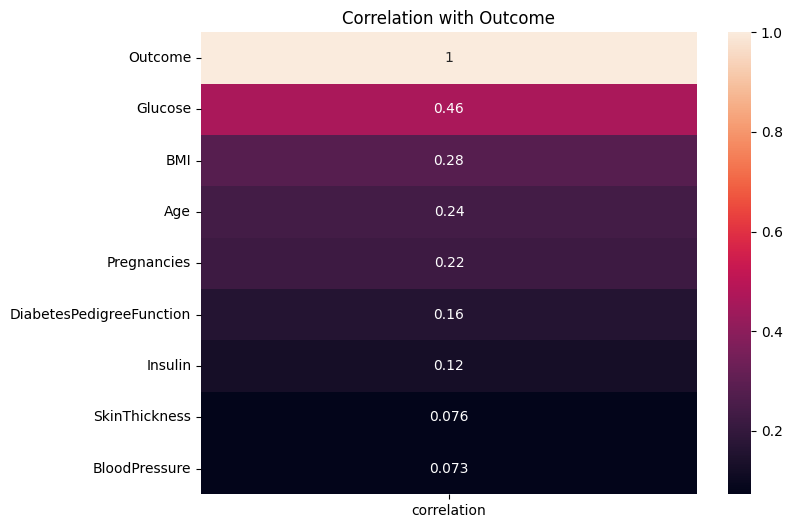

In [38]:
# Calculate the correlation with 'Outcome'
correlation_with_outcome = df.corrwith(df['Outcome']).sort_values(ascending=False)

# Create a heatmap using seaborn for correlation with 'Outcome'
plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(correlation_with_outcome, columns=['correlation']), annot=True)

# Show the plot
plt.title('Correlation with Outcome')
plt.show()

In [39]:
df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.NaN)

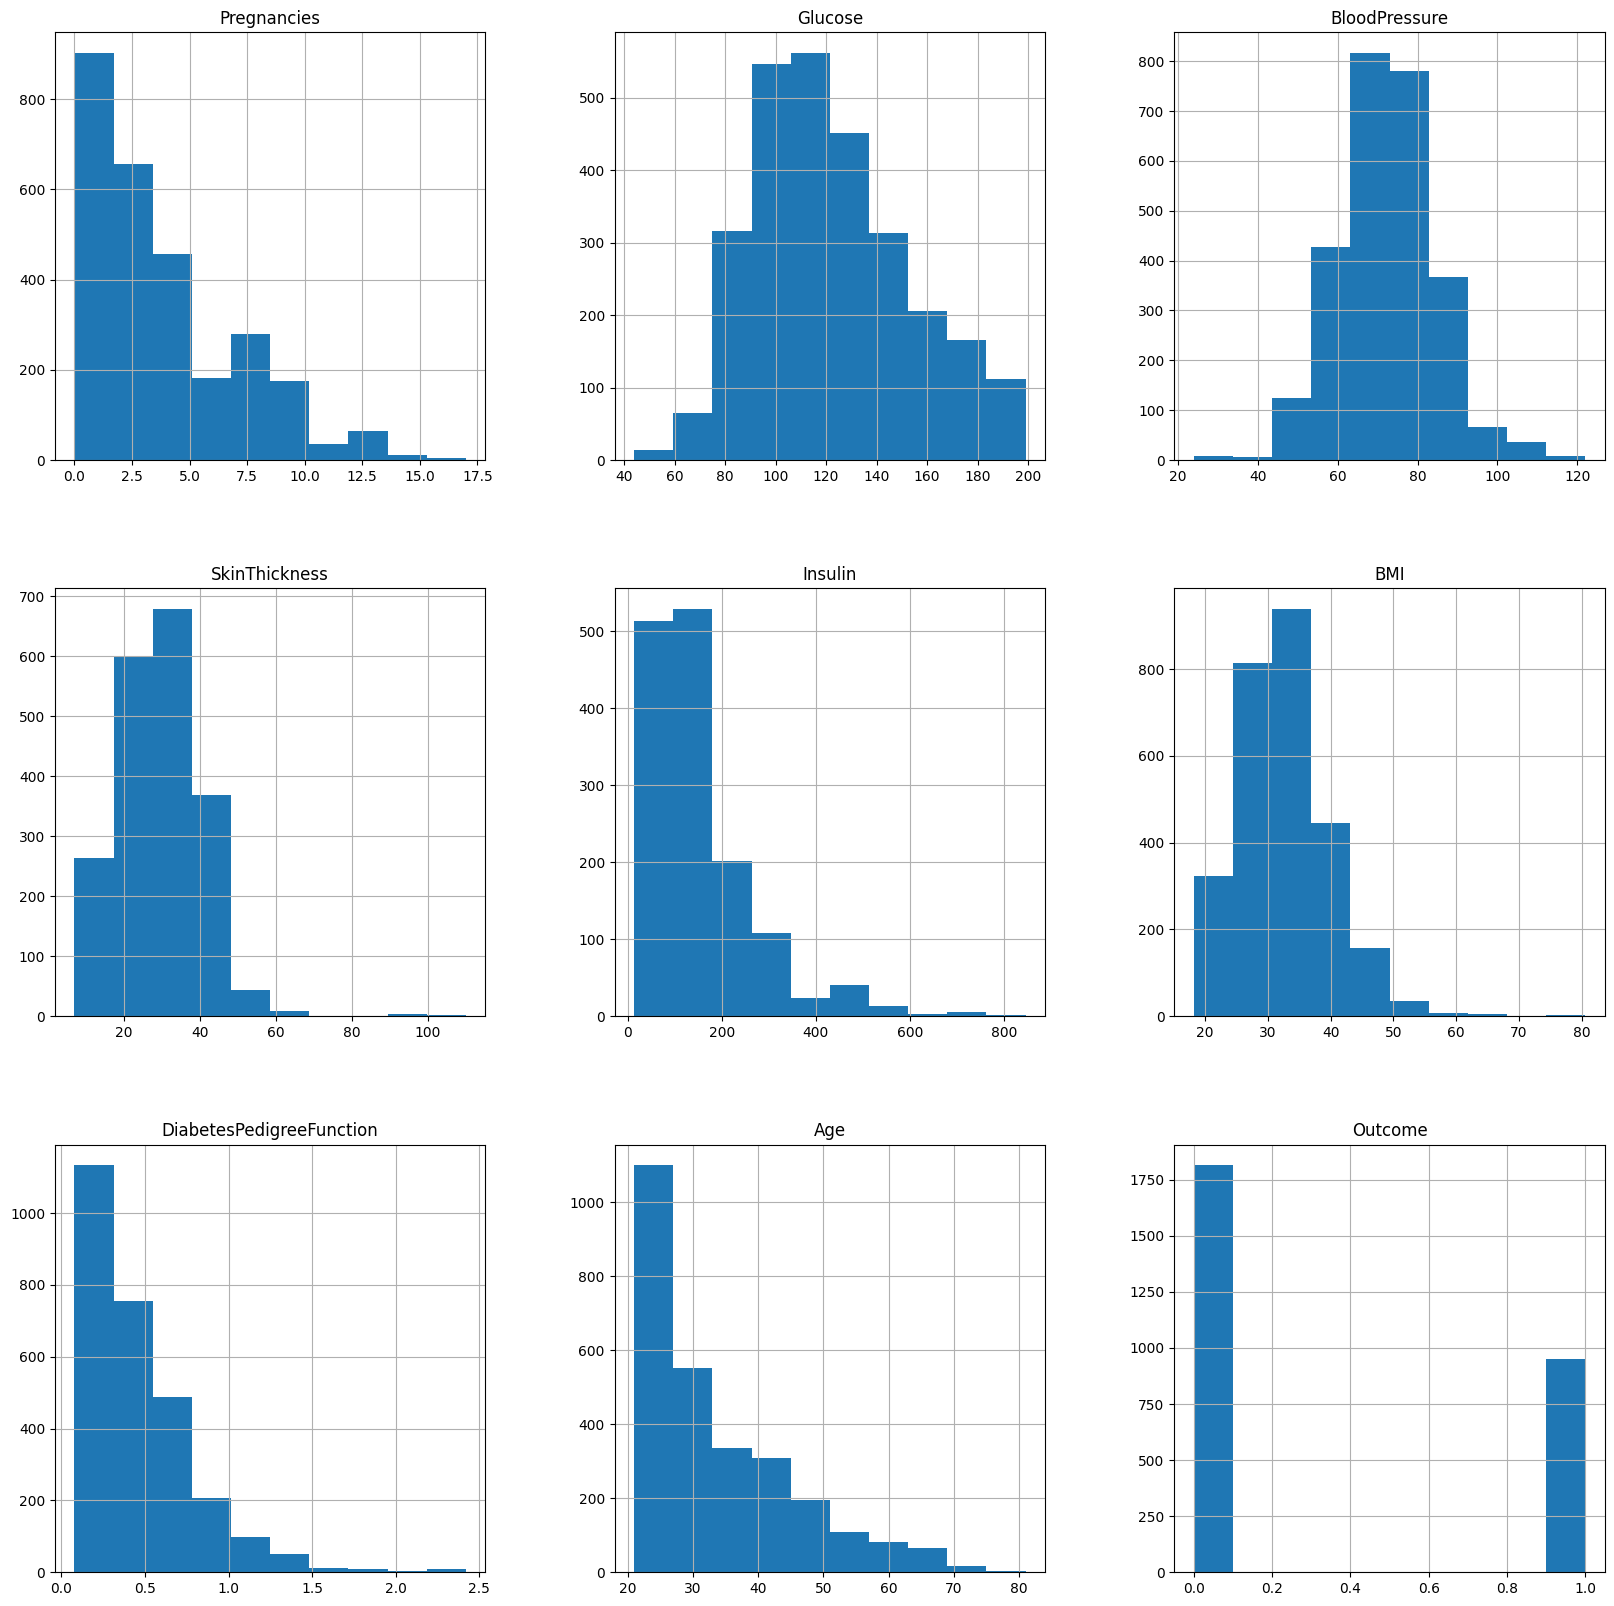

In [40]:
p = df.hist(figsize = (20,20))

In [41]:
df.isna().sum()

Pregnancies                    0
Glucose                       18
BloodPressure                125
SkinThickness                800
Insulin                     1330
BMI                           39
DiabetesPedigreeFunction       0
Age                            0
Outcome                        0
dtype: int64

In [42]:
df_copy = df

In [43]:
# Mengisi Missing Value sesuai dengandistribusi pada tabel
df_copy['Glucose'].fillna(df_copy['Glucose'].mean(), inplace = True)
df_copy['BloodPressure'].fillna(df_copy['BloodPressure'].mean(), inplace = True)
df_copy['SkinThickness'].fillna(df_copy['SkinThickness'].median(), inplace = True)
df_copy['Insulin'].fillna(df_copy['Insulin'].median(), inplace = True)
df_copy['BMI'].fillna(df_copy['BMI'].median(), inplace = True)

C:\Users\dgoza\AppData\Local\Temp\ipykernel_14324\639036552.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Glucose'].fillna(df_copy['Glucose'].mean(), inplace = True)
C:\Users\dgoza\AppData\Local\Temp\ipykernel_14324\639036552.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

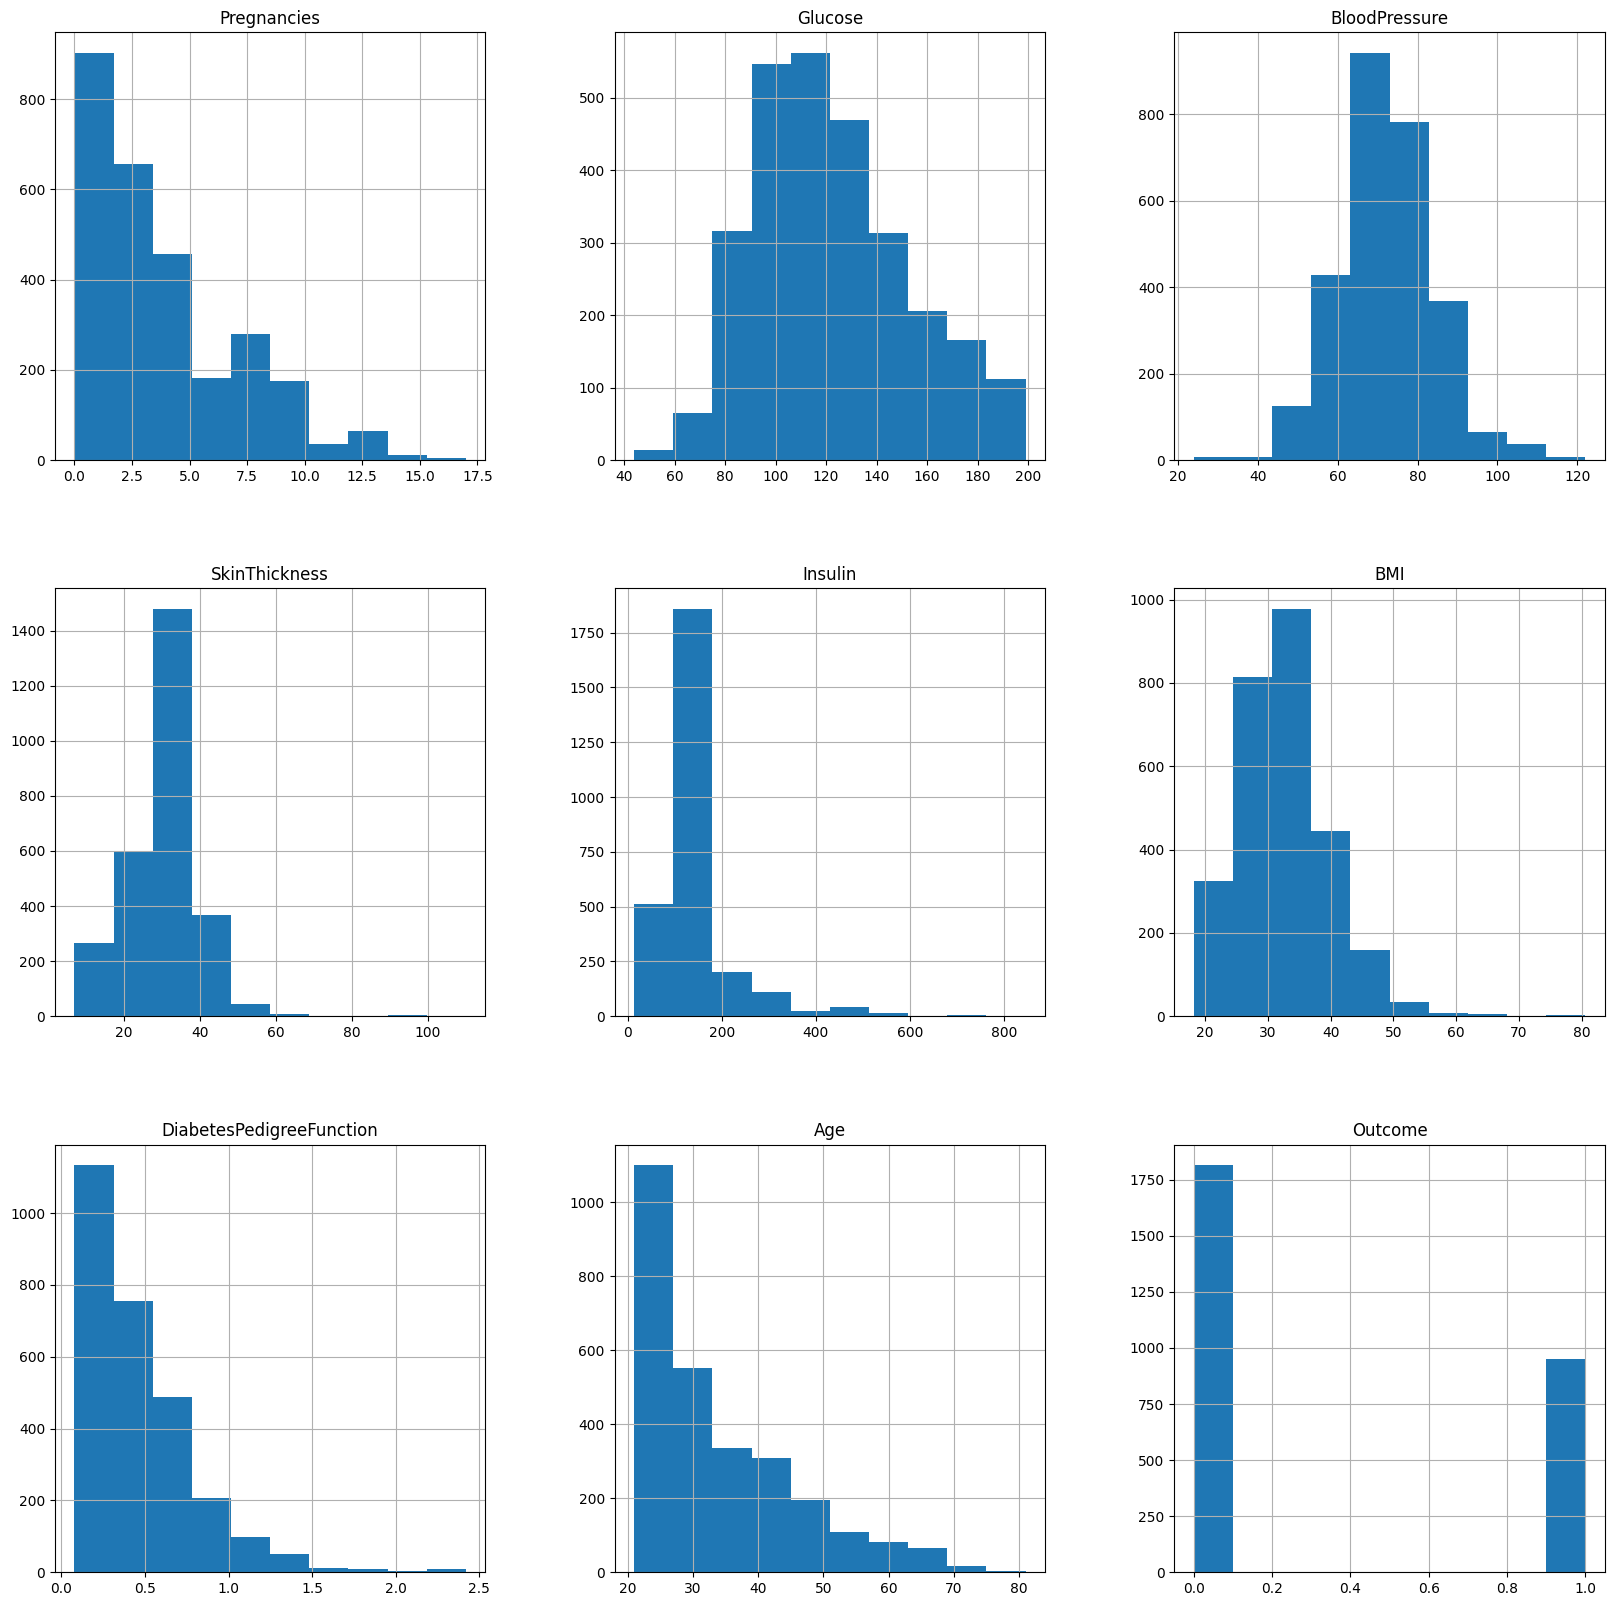

In [44]:
p = df_copy.hist(figsize = (20,20))

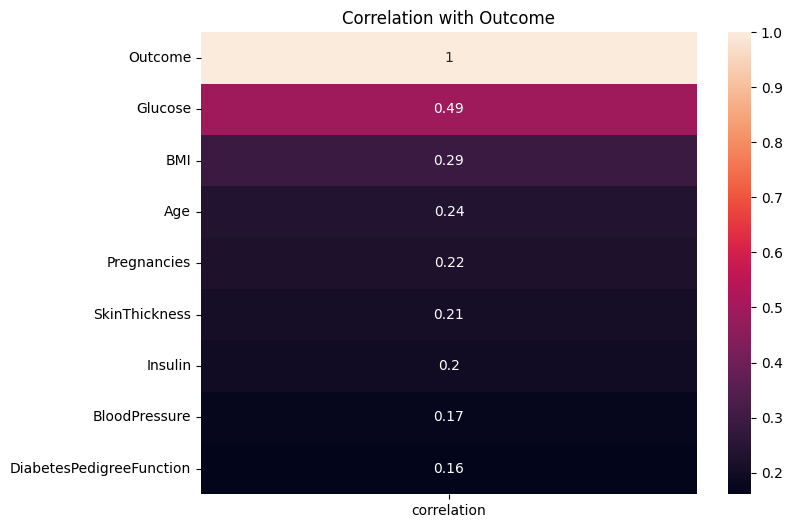

In [45]:
# Correlation after cleaning data
# Calculate the correlation with 'Outcome'
correlation_with_outcome = df_copy.corrwith(df_copy['Outcome']).sort_values(ascending=False)

# Create a heatmap using seaborn for correlation with 'Outcome'
plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(correlation_with_outcome, columns=['correlation']), annot=True)

# Show the plot
plt.title('Correlation with Outcome')
plt.show()

In [54]:
df_copy = df_copy.drop(columns = ['DiabetesPedigreeFunction'])

KeyError: "['DiabetesPedigreeFunction'] not found in axis"

In [55]:
print(df_copy.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'Age', 'Outcome'],
      dtype='object')


In [47]:
from sklearn.model_selection import train_test_split
X = df_copy.drop(columns=['Outcome'])
y = df_copy['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [48]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5)
# Initialize the KNN classifier
k = 3  # Number of neighbors to consider
knn = KNeighborsClassifier(n_neighbors=k)

# Train the classifier
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Calculate accuracy
print(classification_report(y_test, y_pred))
score = cross_val_score(knn, X, y, cv = kf)
print('Cross Validation Score:\n', score)

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       364
           1       0.94      0.92      0.93       190

    accuracy                           0.95       554
   macro avg       0.95      0.94      0.94       554
weighted avg       0.95      0.95      0.95       554

Cross Validation Score:
 [0.96209386 1.         0.99458484 1.         0.98553345]


In [49]:
# Create an SVM classifier
from sklearn.svm import SVC
svm_classifier = SVC()

# Train the classifier
svm_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_classifier.predict(X_test)

# Generate a classification report
print(classification_report(y_test, y_pred))
score = cross_val_score(svm_classifier, X, y, cv = kf)
print('Cross Validation Score:\n', score)

              precision    recall  f1-score   support

           0       0.77      0.90      0.83       364
           1       0.71      0.49      0.58       190

    accuracy                           0.76       554
   macro avg       0.74      0.69      0.70       554
weighted avg       0.75      0.76      0.74       554

Cross Validation Score:
 [0.75090253 0.75451264 0.81227437 0.77034358 0.7721519 ]


In [50]:
from sklearn.naive_bayes import MultinomialNB
# Initialize the MultinomialNB classifier
mnb = MultinomialNB()

# Train the classifier
mnb.fit(X_train, y_train)

# Predictions
y_pred = mnb.predict(X_test)

# Generate a classification report
print(classification_report(y_test, y_pred))
score = cross_val_score(mnb, X, y, cv = kf)
print('Cross Validation Score:\n', score)

              precision    recall  f1-score   support

           0       0.72      0.76      0.74       364
           1       0.48      0.44      0.46       190

    accuracy                           0.65       554
   macro avg       0.60      0.60      0.60       554
weighted avg       0.64      0.65      0.64       554

Cross Validation Score:
 [0.67689531 0.62815884 0.68231047 0.66546112 0.65461121]


In [51]:
from sklearn.naive_bayes import GaussianNB
# Initialize the GaussianNB classifier
gnb = GaussianNB()

# Train the classifier
gnb.fit(X_train, y_train)

# Predictions
y_pred = gnb.predict(X_test)

# Generate a classification report
print(classification_report(y_test, y_pred))
score = cross_val_score(gnb, X, y, cv = kf)
print('Cross Validation Score:\n', score)

              precision    recall  f1-score   support

           0       0.79      0.82      0.80       364
           1       0.62      0.58      0.60       190

    accuracy                           0.74       554
   macro avg       0.71      0.70      0.70       554
weighted avg       0.73      0.74      0.73       554

Cross Validation Score:
 [0.74548736 0.74187726 0.78158845 0.75045208 0.74683544]


In [52]:
from sklearn.linear_model import LogisticRegression
# Initialize the Logistic Regression classifier
lr = LogisticRegression()
# Train the classifier
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Generate a classification report
print(classification_report(y_test, y_pred))
score = cross_val_score(lr, X, y, cv = kf)
print('Cross Validation Score:\n', score)

              precision    recall  f1-score   support

           0       0.79      0.86      0.82       364
           1       0.68      0.55      0.60       190

    accuracy                           0.75       554
   macro avg       0.73      0.71      0.71       554
weighted avg       0.75      0.75      0.75       554

Cross Validation Score:
 [0.75270758 0.75090253 0.81046931 0.76672694 0.77757685]


C:\Users\dgoza\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\dgoza\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_mo

### Pickle the best model (KNN)

In [53]:
import pickle

model_file = open("model.pickle", "wb")
pickle.dump(knn, model_file)